# Семинар по линейной классификации

В этом семинаре мы научимся решать задачи классификации с помощью линейной модели из scikit-learn.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

In [2]:
from pathlib import Path


data_dir = Path("/content/drive/MyDrive/179-ml-course/2024-fall/datasets/african-credit-scoring-challenge")
train_df = pd.read_csv(data_dir / "Train.csv")
test_df = pd.read_csv(data_dir / "Test.csv")

In [3]:
train_df

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68649,ID_244559228408267278,244559,Kenya,228408,267278,Type_1,1460.0,1515.0,2022-07-30,2022-08-06,7,Repeat Loan,438.00,0.300000,455.0,0
68650,ID_260062217784267278,260062,Kenya,217784,267278,Type_1,5029.0,5116.0,2022-07-16,2022-07-23,7,Repeat Loan,1508.70,0.300000,1535.0,0
68651,ID_259137216701267278,259137,Kenya,216701,267278,Type_1,5289.0,5289.0,2022-07-15,2022-07-22,7,Repeat Loan,1586.70,0.300000,1587.0,0
68652,ID_266801303201267278,266801,Kenya,303201,267278,Type_1,3334.0,3334.0,2022-11-23,2022-11-30,7,Repeat Loan,741.09,0.222283,741.0,0


In [8]:
test_df.shape

(18594, 15)

In [4]:
!cat /content/drive/MyDrive/179-ml-course/2024-fall/datasets/african-credit-scoring-challenge/VariableDefinitions.txt

## Description of variables in Train/Test.csv

0. **ID**: A unique identifier for each entry in the dataset.

1. **customer_id**: Unique identifier for each customer in the dataset.

2. **country_id**: Identifier or code representing the country where the customer resides or where the loan was issued.

3. **tbl_loan_id**: Unique identifier for each loan associated with the customer.

4. **Total_Amount**: The total loan amount initially disbursed to the customer.

5. **Total_Amount_to_Repay**: The total amount the customer is expected to repay, including principal, interest, and fees.

6. **loan_type**: The category or type of loan.

7. **disbursement_date**: The date when the loan amount was disbursed to the customer.

8. **duration**: The length of the loan term, typically expressed in days

9. **lender_id**: Unique identifier for the lender or institution that issued the loan.

10. **New_versus_Repeat**: Indicates whether the loan is the customer's first loan ("New") or if the custom

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           68654 non-null  object 
 1   customer_id                  68654 non-null  int64  
 2   country_id                   68654 non-null  object 
 3   tbl_loan_id                  68654 non-null  int64  
 4   lender_id                    68654 non-null  int64  
 5   loan_type                    68654 non-null  object 
 6   Total_Amount                 68654 non-null  float64
 7   Total_Amount_to_Repay        68654 non-null  float64
 8   disbursement_date            68654 non-null  object 
 9   due_date                     68654 non-null  object 
 10  duration                     68654 non-null  int64  
 11  New_versus_Repeat            68654 non-null  object 
 12  Amount_Funded_By_Lender      68654 non-null  float64
 13  Lender_portion_F

In [6]:
train_df["target"].value_counts()

,count
target,
0,67396
1,1258


In [7]:
train_df["target"].value_counts(normalize=True)

,proportion
target,
0,0.981676
1,0.018324


In [9]:
from sklearn.model_selection import train_test_split


simple_features = ["Total_Amount", "Total_Amount_to_Repay", "duration", "Amount_Funded_By_Lender", "Lender_portion_Funded", "Lender_portion_to_be_repaid"]
X_train, X_val, y_train, y_val = train_test_split(train_df[simple_features], train_df["target"], test_size=0.3, random_state=179, stratify=train_df["target"])
X_test = test_df[simple_features]

In [10]:
print(f"{X_train.shape = }")
print(f"{X_val.shape = }")
print(f"{X_test.shape = }")

X_train.shape = (48057, 6)
X_val.shape = (20597, 6)
X_test.shape = (18594, 6)


In [11]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression


logreg = LogisticRegression(class_weight="balanced", random_state=179)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=179)

In [18]:
from sklearn.metrics import classification_report


y_train_pred = logreg.predict(X_train_scaled)
y_val_pred = logreg.predict(X_val_scaled)

print("Метрики на трейне")
print(classification_report(y_train, y_train_pred))

print("Метрики на валидации")
print(classification_report(y_val, y_val_pred))

Метрики на трейне
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     47176
           1       0.36      0.67      0.47       881

    accuracy                           0.97     48057
   macro avg       0.68      0.82      0.73     48057
weighted avg       0.98      0.97      0.98     48057

Метрики на валидации
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     20220
           1       0.33      0.63      0.44       377

    accuracy                           0.97     20597
   macro avg       0.66      0.80      0.71     20597
weighted avg       0.98      0.97      0.97     20597



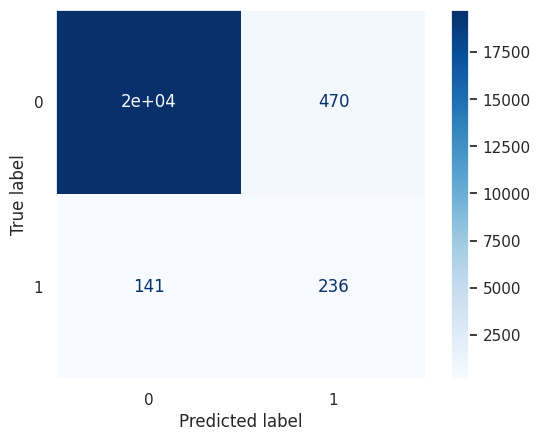

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay


cm = ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap=plt.cm.Blues)
cm.ax_.grid(False)  # отключаем координатную сетку

In [20]:
# визуализация коэффициентов линейной регрессии
def visualize_coefficients(coefs, feature_names: list[str], top_n: int) -> None:
    """Функция для визуализации коэффициентов линейной регрессии.

    Параметры:
        coefs: коэффициенты модели (model.coef_)
        feature_names: названия признаков (X_train.columns)
        top_n: вывести top_n самых положительных и top_n самых отрицательных признаков
    """
    feature_names = np.array(feature_names)
    if top_n * 2 > len(coefs):
        n_pos = len(coefs) // 2
        n_neg = len(coefs) - n_pos
    else:
        n_pos, n_neg = top_n, top_n
    # нам нужно найти индексы top_n наибольших и top_n наименьших коэффициентов
    min_coef_idxs = np.argsort(coefs)[:n_neg]
    max_coef_idxs = np.argsort(coefs)[len(coefs) - n_pos:]
    # соответствующие имена фичей
    top_feature_names = np.concatenate((feature_names[min_coef_idxs], feature_names[max_coef_idxs]))
    # отобразим на bar-графике
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(np.arange(n_neg), coefs[min_coef_idxs], color=sns.xkcd_rgb["mauve"], hatch="/")
    ax.bar(np.arange(n_neg, n_neg + n_pos), coefs[max_coef_idxs], color=sns.xkcd_rgb["teal"], hatch="\\")
    ax.set_xticks(np.arange(0, n_neg + n_pos))
    ax.set_xticklabels(top_feature_names, rotation=45, ha="right", fontsize=14)
    plt.show()

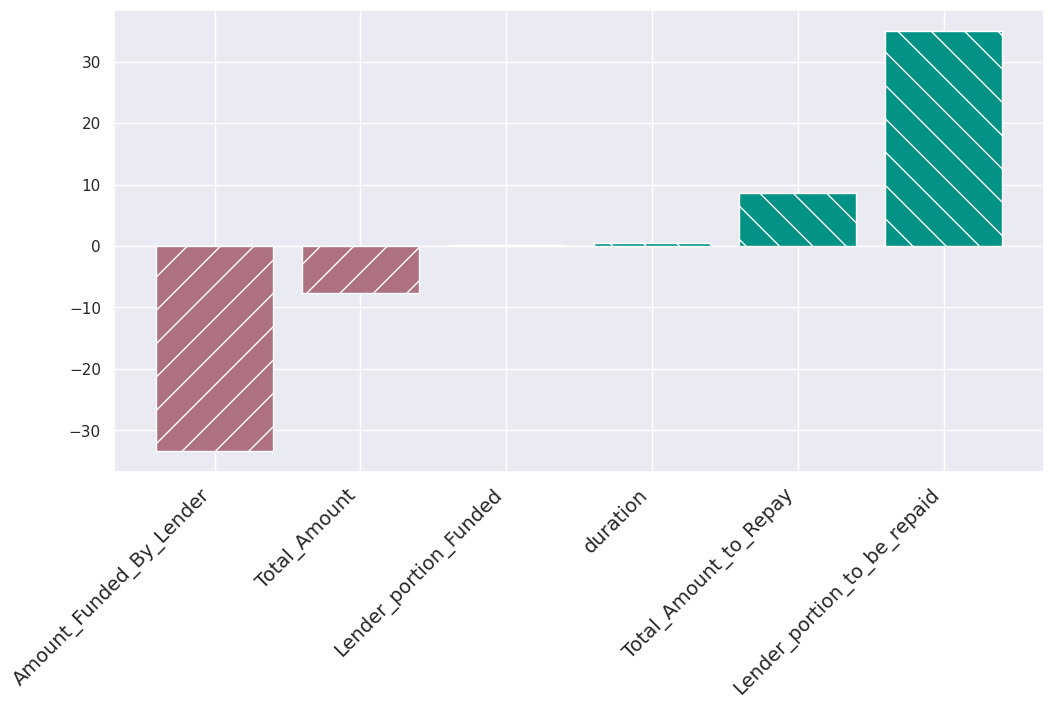

In [21]:
visualize_coefficients(logreg.coef_.squeeze(), feature_names=X_train.columns, top_n=3)

In [22]:
y_test_pred = logreg.predict(X_test_scaled)

In [23]:
submission = test_df[["ID"]].copy()
submission["target"] = y_test_pred

submission.head()

,ID,target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0


In [24]:
submission

,ID,target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0
...,...,...
18589,ID_297596365331297183,0
18590,ID_259715231897267278,0
18591,ID_296701364008297183,0
18592,ID_268271242864267278,0


In [25]:
submission.to_csv("simple-submission.csv", index=False)